In [21]:
import plotly.io as pio
import plotly.graph_objects as go
import pandas as pd

# 1. Configuración del Tema Deep Ocean / Cyber-Blue
# Esto hace que todos tus gráficos de Plotly nazcan con el estilo del repo de referencia
pio.templates["cyber_blue"] = go.layout.Template(
    layout=dict(
        paper_bgcolor='#050505',
        plot_bgcolor='#050505',
        font=dict(color='#00D1FF', family="Inter, Arial"),
        xaxis=dict(gridcolor='#1A1A1A', showgrid=True, zeroline=False),
        yaxis=dict(gridcolor='#1A1A1A', showgrid=True, zeroline=False),
        colorway=['#00D1FF', '#007BFF', '#004A99', '#B8962E']
    )
)
pio.templates.default = "cyber_blue"

print(" Sistema Visual 'Cyber-Blue' inicializado con éxito.")

 Sistema Visual 'Cyber-Blue' inicializado con éxito.


In [22]:
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Configuración de página minimalista
st.set_page_config(layout="wide", page_title="TELCO CHURN MLOPS")

def inject_styles():
    st.markdown("""
        <style>
        @import url('https://rsms.me/inter/inter.css');
        html, body, [class*="css"] { font-family: 'Inter', sans-serif; background-color: #050505; color: #E0E0E0; }
        
        /* Navegación Sidebar */
        .toc-item {
            padding: 8px 12px;
            border-radius: 4px;
            margin-bottom: 4px;
            border-left: 2px solid transparent;
            transition: 0.3s;
        }
        .toc-item:hover {
            background: rgba(0, 209, 255, 0.05);
            border-left: 2px solid #00D1FF;
        }
        .toc-link {
            text-decoration: none;
            color: #888 !important;
            font-size: 13px;
            font-weight: 500;
        }
        
        /* Contenedores de Sección */
        .section-container {
            padding: 40px 0;
            border-bottom: 1px solid rgba(255, 255, 255, 0.05);
        }
        
        /* Metric Cards High-Density */
        div[data-testid="stMetric"] {
            background: #0A0A0A;
            border: 1px solid #1A1A1A;
            padding: 15px;
            border-radius: 4px;
        }
        </style>
    """, unsafe_allow_html=True)

def render_sidebar_toc():
    with st.sidebar:
        st.markdown("<p style='color:#00D1FF; font-weight:800; font-size:11px; letter-spacing:1px;'>SISTEMA DE NAVEGACIÓN</p>", unsafe_allow_html=True)
        
        sections = [
            ("Overview & KPIs", "overview"),
            ("Distribuciones", "distribuciones"),
            ("Análisis Categórico", "categorico"),
            ("Correlaciones", "correlaciones"),
            ("Churn Analysis", "churn"),
            ("Missing & Outliers", "outliers"),
            ("Insights Automáticos", "insights")
        ]
        
        for name, anchor in sections:
            st.markdown(f"""
                <div class="toc-item">
                    <a href="#{anchor}" class="toc-link">{name.upper()}</a>
                </div>
            """, unsafe_allow_html=True)
        
        st.markdown("---")

2026-05-09 17:44:41.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [23]:
def render_content(df):
    inject_styles()
    render_sidebar_toc()

    # --- SECCIÓN 1: OVERVIEW ---
    st.markdown('<div id="overview" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>1. OVERVIEW & STRATEGIC KPIs</h2>", unsafe_allow_html=True)
    
    # 6 KPI Cards
    k1, k2, k3, k4, k5, k6 = st.columns(6)
    k1.metric("Total Customers", len(df))
    k2.metric("Churn Rate", f"{(df['Churn']=='Yes').mean()*100:.1f}%")
    k3.metric("Tenure Mean", f"{df['tenure'].mean():.1f}m")
    k4.metric("Total Revenue", f"${df['MonthlyCharges'].sum()/1e6:.2f}M")
    k5.metric("Avg Monthly", f"${df['MonthlyCharges'].mean():.2f}")
    k6.metric("Active Services", df[['PhoneService', 'InternetService']].notnull().sum().sum())

    col_a, col_b = st.columns([1, 2])
    with col_a:
        st.markdown("<p style='font-size:12px; color:#555;'>CHURN DISTRIBUTION</p>", unsafe_allow_html=True)
        # Aquí iría el Donut Churn con Plotly
    with col_b:
        st.markdown("<p style='font-size:12px; color:#555;'>SCHEMA & STATISTICS</p>", unsafe_allow_html=True)
        st.dataframe(df.describe().T, use_container_width=True)
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 2: DISTRIBUCIONES ---
    st.markdown('<div id="distribuciones" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>2. DISTRIBUCIONES DE VARIABLES</h2>", unsafe_allow_html=True)
    # Aquí: Histograma con densidad + Box plots (3 vars) + Violin plot
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 3: CATEGÓRICO ---
    st.markdown('<div id="categorico" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>3. ANÁLISIS CATEGÓRICO</h2>", unsafe_allow_html=True)
    # Aquí: Bar horizontal + Churn rate por categoría + Tabla frecuencias
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 4: CORRELACIONES ---
    st.markdown('<div id="correlaciones" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>4. MATRIZ DE CORRELACIÓN</h2>", unsafe_allow_html=True)
    # Aquí: Heatmap Pearson + Correlación target + Scatter matrix
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 5: CHURN ANALYSIS ---
    st.markdown('<div id="churn" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>5. PROFUNDIZACIÓN EN CHURN</h2>", unsafe_allow_html=True)
    # Aquí: Heatmap segmentado + Cohorts tenure + Scatter Monthly vs Tenure
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 6: OUTLIERS ---
    st.markdown('<div id="outliers" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>6. MISSING & OUTLIERS DIAGNOSTIC</h2>", unsafe_allow_html=True)
    # Aquí: Missing values bar + IQR table + Box plot extendido
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 7: INSIGHTS ---
    st.markdown('<div id="insights" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>7. INSIGHTS ESTRATÉGICOS</h2>", unsafe_allow_html=True)
    # Aquí: 6 insight pills + Risk matrix + Revenue impact
    st.markdown('</div>', unsafe_allow_html=True)

In [24]:
import streamlit as st
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Configuración de página con estética minimalista
st.set_page_config(layout="wide", page_title="Telco Churn Analytics")

def apply_global_filters(df):
    """
    Motor de filtrado reactivo para el dashboard.
    """
    with st.sidebar:
        st.markdown("### CONFIGURACIÓN DE FILTROS")
        st.markdown("---")
        
        # 1. Filtro: Tipo de Contrato (Multiselect)
        contract_options = df['Contract'].unique().tolist()
        selected_contracts = st.multiselect(
            "Contract Type", 
            options=contract_options, 
            default=contract_options
        )
        
        # 2. Filtro: Internet Service (Multiselect)
        internet_options = df['InternetService'].unique().tolist()
        selected_internet = st.multiselect(
            "Internet Service", 
            options=internet_options, 
            default=internet_options
        )
        
        # 3. Filtro: Tenure Range (Slider)
        min_tenure = int(df['tenure'].min())
        max_tenure = int(df['tenure'].max())
        selected_tenure = st.sidebar.slider(
            "Tenure Range (Months)", 
            min_tenure, max_tenure, (min_tenure, max_tenure)
        )

    # Aplicación de filtros al DataFrame
    filtered_df = df[
        (df['Contract'].isin(selected_contracts)) &
        (df['InternetService'].isin(selected_internet)) &
        (df['tenure'].between(selected_tenure[0], selected_tenure[1]))
    ]
    
    return filtered_df

# Inyección de CSS para estética Cyber-Blue (Sin stickers)
st.markdown("""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;800&display=swap');
    
    html, body, [class*="css"] { font-family: 'Inter', sans-serif; }
    
    /* Contenedor de Sidebar */
    section[data-testid="stSidebar"] {
        background-color: #050505;
        border-right: 1px solid rgba(0, 209, 255, 0.2);
    }
    
    /* Títulos de Sidebar */
    .sidebar-title {
        color: #00D1FF;
        font-size: 14px;
        font-weight: 800;
        letter-spacing: 1px;
        text-transform: uppercase;
    }
    </style>
""", unsafe_allow_html=True)

2026-05-09 17:44:41.106 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:44:41.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:44:41.150 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:44:41.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [25]:
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Configuración de página minimalista
st.set_page_config(layout="wide", page_title="TELCO CHURN MLOPS")

def inject_styles():
    st.markdown("""
        <style>
        @import url('https://rsms.me/inter/inter.css');
        html, body, [class*="css"] { font-family: 'Inter', sans-serif; background-color: #050505; color: #E0E0E0; }
        
        /* Navegación Sidebar */
        .toc-item {
            padding: 8px 12px;
            border-radius: 4px;
            margin-bottom: 4px;
            border-left: 2px solid transparent;
            transition: 0.3s;
        }
        .toc-item:hover {
            background: rgba(0, 209, 255, 0.05);
            border-left: 2px solid #00D1FF;
        }
        .toc-link {
            text-decoration: none;
            color: #888 !important;
            font-size: 13px;
            font-weight: 500;
        }
        
        /* Contenedores de Sección */
        .section-container {
            padding: 40px 0;
            border-bottom: 1px solid rgba(255, 255, 255, 0.05);
        }
        
        /* Metric Cards High-Density */
        div[data-testid="stMetric"] {
            background: #0A0A0A;
            border: 1px solid #1A1A1A;
            padding: 15px;
            border-radius: 4px;
        }
        </style>
    """, unsafe_allow_html=True)

def render_sidebar_toc():
    with st.sidebar:
        st.markdown("<p style='color:#00D1FF; font-weight:800; font-size:11px; letter-spacing:1px;'>SISTEMA DE NAVEGACIÓN</p>", unsafe_allow_html=True)
        
        sections = [
            ("Overview & KPIs", "overview"),
            ("Distribuciones", "distribuciones"),
            ("Análisis Categórico", "categorico"),
            ("Correlaciones", "correlaciones"),
            ("Churn Analysis", "churn"),
            ("Missing & Outliers", "outliers"),
            ("Insights Automáticos", "insights")
        ]
        
        for name, anchor in sections:
            st.markdown(f"""
                <div class="toc-item">
                    <a href="#{anchor}" class="toc-link">{name.upper()}</a>
                </div>
            """, unsafe_allow_html=True)
        
        st.markdown("---")

2026-05-09 17:44:41.215 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [26]:
def render_content(df):
    inject_styles()
    render_sidebar_toc()

    # --- SECCIÓN 1: OVERVIEW ---
    st.markdown('<div id="overview" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>1. OVERVIEW & STRATEGIC KPIs</h2>", unsafe_allow_html=True)
    
    # 6 KPI Cards
    k1, k2, k3, k4, k5, k6 = st.columns(6)
    k1.metric("Total Customers", len(df))
    k2.metric("Churn Rate", f"{(df['Churn']=='Yes').mean()*100:.1f}%")
    k3.metric("Tenure Mean", f"{df['tenure'].mean():.1f}m")
    k4.metric("Total Revenue", f"${df['MonthlyCharges'].sum()/1e6:.2f}M")
    k5.metric("Avg Monthly", f"${df['MonthlyCharges'].mean():.2f}")
    k6.metric("Active Services", df[['PhoneService', 'InternetService']].notnull().sum().sum())

    col_a, col_b = st.columns([1, 2])
    with col_a:
        st.markdown("<p style='font-size:12px; color:#555;'>CHURN DISTRIBUTION</p>", unsafe_allow_html=True)
        # Aquí iría el Donut Churn con Plotly
    with col_b:
        st.markdown("<p style='font-size:12px; color:#555;'>SCHEMA & STATISTICS</p>", unsafe_allow_html=True)
        st.dataframe(df.describe().T, use_container_width=True)
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 2: DISTRIBUCIONES ---
    st.markdown('<div id="distribuciones" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>2. DISTRIBUCIONES DE VARIABLES</h2>", unsafe_allow_html=True)
    # Aquí: Histograma con densidad + Box plots (3 vars) + Violin plot
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 3: CATEGÓRICO ---
    st.markdown('<div id="categorico" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>3. ANÁLISIS CATEGÓRICO</h2>", unsafe_allow_html=True)
    # Aquí: Bar horizontal + Churn rate por categoría + Tabla frecuencias
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 4: CORRELACIONES ---
    st.markdown('<div id="correlaciones" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>4. MATRIZ DE CORRELACIÓN</h2>", unsafe_allow_html=True)
    # Aquí: Heatmap Pearson + Correlación target + Scatter matrix
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 5: CHURN ANALYSIS ---
    st.markdown('<div id="churn" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>5. PROFUNDIZACIÓN EN CHURN</h2>", unsafe_allow_html=True)
    # Aquí: Heatmap segmentado + Cohorts tenure + Scatter Monthly vs Tenure
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 6: OUTLIERS ---
    st.markdown('<div id="outliers" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>6. MISSING & OUTLIERS DIAGNOSTIC</h2>", unsafe_allow_html=True)
    # Aquí: Missing values bar + IQR table + Box plot extendido
    st.markdown('</div>', unsafe_allow_html=True)

    # --- SECCIÓN 7: INSIGHTS ---
    st.markdown('<div id="insights" class="section-container">', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>7. INSIGHTS ESTRATÉGICOS</h2>", unsafe_allow_html=True)
    # Aquí: 6 insight pills + Risk matrix + Revenue impact
    st.markdown('</div>', unsafe_allow_html=True)

<div style="background-color: #111; padding: 25px; border-radius: 12px; border-left: 6px solid #00D1FF; margin-bottom: 20px;">
    <h1 style="color: #00D1FF; font-family: 'Inter', sans-serif; margin: 0;"> Exploratory Data Analysis</h1>
    <p style="color: #888; font-size: 1.1em; margin-top: 10px;">Pipeline de Diagnóstico | Telco Churn Project</p>
</div>

#  Análisis Exploratorio de Datos — Telco Customer Churn
**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn  
**Registros:** 7 043 clientes · **Variables:** 21  
**Objetivo:** Comprender los factores asociados al abandono de clientes (Churn)



## 0. Configuración del entorno

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── Paleta profesional ────────────────────────────────────────
COLOR_NO   = '#2ECC71'   # Verde  → No Churn
COLOR_YES  = '#E74C3C'   # Rojo   → Churn
COLOR_MAIN = '#2C3E50'   # Azul oscuro
PALETTE    = [COLOR_NO, COLOR_YES]

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.edgecolor':    '#DEE2E6',
    'axes.linewidth':    1.2,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'grid.color':        '#DEE2E6',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})


def display_table(df, caption=None):
    if caption:
        display(HTML(f"<div style='font-family: DejaVu Sans; color: {COLOR_MAIN}; font-size: 1rem; font-weight: 700; margin-bottom: 0.35rem;'>{caption}</div>"))

    styles = [
        {'selector': 'thead', 'props': [('background-color', COLOR_MAIN), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F8F9FA')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#EAF2F8')]},
        {'selector': 'th, td', 'props': [('padding', '6px 10px'), ('border', '1px solid #DEE2E6'), ('text-align', 'left')]},
    ]

    display(df.style.set_table_styles(styles).set_properties(**{'font-family': 'DejaVu Sans'}))


env = pd.DataFrame({
    'Librería': ['Pandas', 'NumPy', 'Seaborn'],
    'Versión': [pd.__version__, np.__version__, sns.__version__]
})

display_table(env, caption='Entorno configurado')


,Librería,Versión
0,Pandas,2.3.3
1,NumPy,1.25.2
2,Seaborn,0.12.2


In [28]:
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Configuración de página minimalista
st.set_page_config(layout="wide", page_title="TELCO CHURN MLOPS")

def inject_styles():
    st.markdown("""
        <style>
        @import url('https://rsms.me/inter/inter.css');
        html, body, [class*="css"] { font-family: 'Inter', sans-serif; background-color: #050505; color: #E0E0E0; }
        
        /* Navegación Sidebar */
        .toc-item {
            padding: 8px 12px;
            border-radius: 4px;
            margin-bottom: 4px;
            border-left: 2px solid transparent;
            transition: 0.3s;
        }
        .toc-item:hover {
            background: rgba(0, 209, 255, 0.05);
            border-left: 2px solid #00D1FF;
        }
        .toc-link {
            text-decoration: none;
            color: #888 !important;
            font-size: 13px;
            font-weight: 500;
        }
        
        /* Contenedores de Sección */
        .section-container {
            padding: 40px 0;
            border-bottom: 1px solid rgba(255, 255, 255, 0.05);
        }
        
        /* Metric Cards High-Density */
        div[data-testid="stMetric"] {
            background: #0A0A0A;
            border: 1px solid #1A1A1A;
            padding: 15px;
            border-radius: 4px;
        }
        </style>
    """, unsafe_allow_html=True)

def render_sidebar_toc():
    with st.sidebar:
        st.markdown("<p style='color:#00D1FF; font-weight:800; font-size:11px; letter-spacing:1px;'>SISTEMA DE NAVEGACIÓN</p>", unsafe_allow_html=True)
        
        sections = [
            ("Overview & KPIs", "overview"),
            ("Distribuciones", "distribuciones"),
            ("Análisis Categórico", "categorico"),
            ("Correlaciones", "correlaciones"),
            ("Churn Analysis", "churn"),
            ("Missing & Outliers", "outliers"),
            ("Insights Automáticos", "insights")
        ]
        
        for name, anchor in sections:
            st.markdown(f"""
                <div class="toc-item">
                    <a href="#{anchor}" class="toc-link">{name.upper()}</a>
                </div>
            """, unsafe_allow_html=True)
        
        st.markdown("---")

2026-05-09 17:44:41.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [29]:
import streamlit as st

def render_sidebar_navigation():
    with st.sidebar:
        st.markdown("<p style='color:#00D1FF; font-weight:800; font-size:11px; letter-spacing:1px; margin-bottom:20px;'>ESTRUCTURA ANALÍTICA</p>", unsafe_allow_html=True)
        
        # Estructura detallada con hipervínculos de anclaje
        navigation_html = """
        <div style="line-height: 1.8;">
            <a href="#arquitectura-datos" style="color: #00D1FF; text-decoration: none; font-size: 13px; font-weight: 600;">1. Arquitectura del Conjunto de Datos</a><br>
            
            <a href="#univariado" style="color: #00D1FF; text-decoration: none; font-size: 13px; font-weight: 600;">2. Análisis Univariado</a><br>
            <div style="padding-left: 15px; border-left: 1px solid #1A1A1A; margin: 5px 0 10px 5px;">
                <a href="#tenure" style="color: #888; text-decoration: none; font-size: 12px;">• Antigüedad (Tenure)</a><br>
                <a href="#monthly-charges" style="color: #888; text-decoration: none; font-size: 12px;">• Cargos Mensuales</a><br>
                <a href="#total-charges" style="color: #888; text-decoration: none; font-size: 12px;">• Cargos Totales</a><br>
                <a href="#univariado-resumen" style="color: #888; text-decoration: none; font-size: 12px;">• Síntesis y Resumen Descriptivo</a>
            </div>

            <a href="#bivariado" style="color: #00D1FF; text-decoration: none; font-size: 13px; font-weight: 600;">3. Análisis Bivariado</a><br>
            <div style="padding-left: 15px; border-left: 1px solid #1A1A1A; margin: 5px 0 10px 5px;">
                <a href="#cat-target" style="color: #888; text-decoration: none; font-size: 12px;">• Var. Categóricas vs Variable Objetivo</a><br>
                <a href="#num-target" style="color: #888; text-decoration: none; font-size: 12px;">• Var. Numéricas vs Variable Objetivo</a>
            </div>

            <a href="#dependencia" style="color: #00D1FF; text-decoration: none; font-size: 13px; font-weight: 600;">4. Análisis de Dependencia</a><br>
            <a href="#pca" style="color: #00D1FF; text-decoration: none; font-size: 13px; font-weight: 600;">5. Análisis de Componentes Principales (PCA)</a><br>
            <a href="#insights" style="color: #00D1FF; text-decoration: none; font-size: 13px; font-weight: 600;">6. Conclusiones y Hallazgos</a>
        </div>
        """
        st.markdown(navigation_html, unsafe_allow_html=True)
        st.markdown("---")

## 1. Carga y Vista General del Dataset

### 1.1 Carga de datos

### 1.2 Tipos de variables y estructura

### 1.3 Mapa de calor de valores faltantes

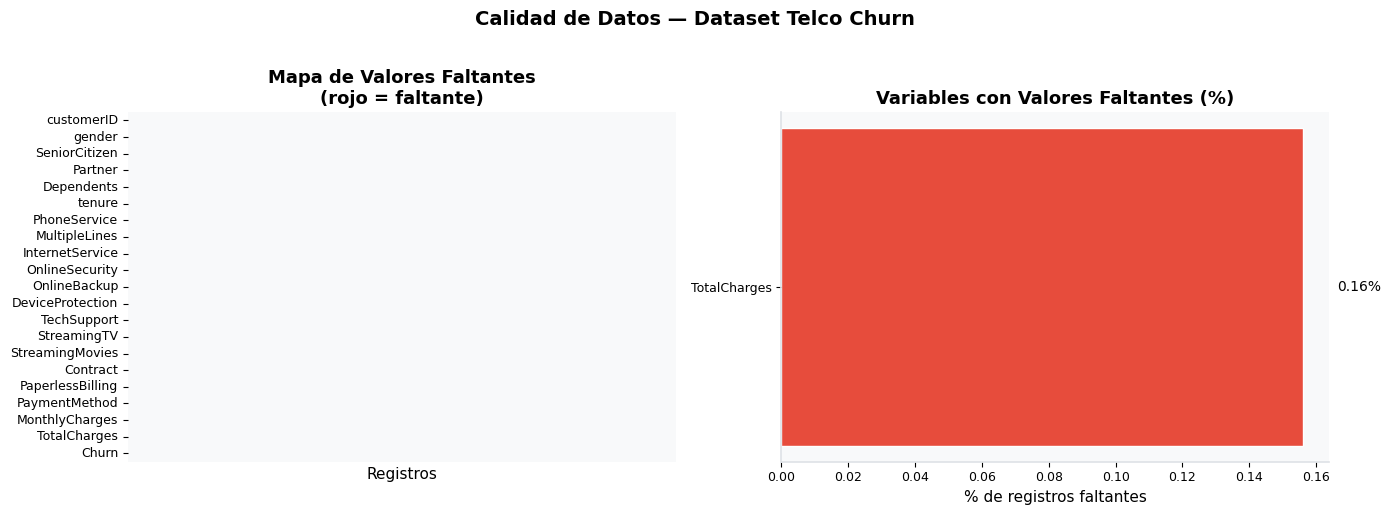

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: heatmap de nulos
missing = df.isnull().astype(int)
sns.heatmap(missing.T, ax=axes[0], cbar=False,
            cmap=['#F8F9FA', '#E74C3C'], yticklabels=True,
            xticklabels=False, linewidths=0)
axes[0].set_title('Mapa de Valores Faltantes\n(rojo = faltante)')
axes[0].set_xlabel('Registros')

# Panel 2: barras con % de nulos
pct_null = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
pct_null = pct_null[pct_null > 0]
if len(pct_null) > 0:
    axes[1].barh(pct_null.index, pct_null.values,
                 color=COLOR_YES, edgecolor='white')
    axes[1].set_title('Variables con Valores Faltantes (%)')
    axes[1].set_xlabel('% de registros faltantes')
    for i, v in enumerate(pct_null.values):
        axes[1].text(v + 0.01, i, f'{v:.2f}%', va='center')
else:
    axes[1].text(0.5, 0.5, 'Sin valores faltantes\n(excepto TotalCharges)',
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Valores Faltantes (%)')
    axes[1].axis('off')

plt.suptitle('Calidad de Datos — Dataset Telco Churn',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

`TotalCharges` presenta 11 valores faltantes (<0.2%) correspondientes a clientes sin historial de facturación (probablemente dados de alta recientemente). Se eliminan antes del modelado sin impacto estadístico relevante.

## 2. Análisis de la Variable Objetivo — Churn

AttributeError: module 'numpy' has no attribute 'matrix'

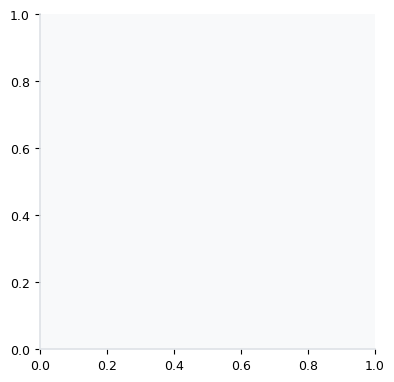

In [31]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: Donut chart ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
wedges, texts, autotexts = ax1.pie(
    churn_counts, labels=['No Churn', 'Churn'],
    colors=PALETTE, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5))
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
ax1.set_title('Distribución Global de Churn')
centre = plt.Circle((0,0), 0.40, fc='white')
ax1.add_patch(centre)
ax1.text(0, 0, f'{churn_pct["Yes"]:.1f}%\nChurn',
         ha='center', va='center', fontsize=11, fontweight='bold', color=COLOR_YES)

# ── Panel 2: Barras con conteos ──────────────────────────────
ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(['No Churn', 'Churn'], churn_counts,
               color=PALETTE, edgecolor='white', linewidth=1.5, width=0.55)
ax2.set_title('Conteo por Clase')
ax2.set_ylabel('Número de clientes')
ax2.grid(True, axis='y')
for bar, cnt, pct in zip(bars, churn_counts, churn_pct):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{cnt:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# ── Panel 3: Texto con métricas clave ───────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
ratio = churn_counts['No'] / churn_counts['Yes']
metricas = [
    ('Total clientes',    f"{len(df):,}"),
    ('No abandonan',      f"{churn_counts['No']:,}  ({churn_pct['No']:.1f}%)"),
    ('Sí abandonan',      f"{churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)"),
    ('Ratio No/Sí',       f"{ratio:.2f} : 1"),
    ('Desbalance',        'MODERADO'),
    ('Métrica sugerida',  'F1-Score / AUC'),
]
y = 0.92
for label, val in metricas:
    ax3.text(0.05, y, label + ':', fontsize=10, color='#555', transform=ax3.transAxes)
    ax3.text(0.55, y, val,         fontsize=10, fontweight='bold', transform=ax3.transAxes)
    y -= 0.14
ax3.set_title('Resumen Estadístico')
ax3.add_patch(mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
    boxstyle='round,pad=0.02', linewidth=1.5,
    edgecolor='#DEE2E6', facecolor='#F8F9FA', transform=ax3.transAxes))

plt.suptitle('Variable Objetivo: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

metricas_df = pd.DataFrame(metricas, columns=['Métrica', 'Valor'])
display_table(metricas_df, caption='Resumen de métricas de Churn')


El dataset presenta un desbalance moderado de **73.5% / 26.5%**. Aunque no es extremo, un clasificador trivial que prediga siempre "No Churn" obtendría 73.5% de accuracy — lo que sería completamente engañoso. Por ello se priorizan F1-Score y AUC-ROC como métricas de evaluación.

## 3. Análisis de Variables Numéricas

### 3.1 Estadísticas descriptivas

In [ ]:
desc = df[num_cols].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)
desc['skew']   = df[num_cols].skew().round(3)
desc['kurt']   = df[num_cols].kurt().round(3)

display_table(desc.round(2), caption='Estadísticas descriptivas extendidas')


,count,mean,std,min,25%,50%,75%,max,CV (%),skew,kurt
tenure,7043.000000,32.370000,24.560000,0.000000,9.000000,29.000000,55.000000,72.000000,75.900000,0.240000,-1.390000
MonthlyCharges,7043.000000,64.760000,30.090000,18.250000,35.500000,70.350000,89.850000,118.750000,46.500000,-0.220000,-1.260000
TotalCharges,7032.000000,2283.300000,2266.770000,18.800000,401.450000,1397.480000,3794.740000,8684.800000,99.300000,0.960000,-0.230000


### 3.2 Distribuciones con KDE — comparación Churn vs No Churn

AttributeError: module 'numpy' has no attribute 'matrix'

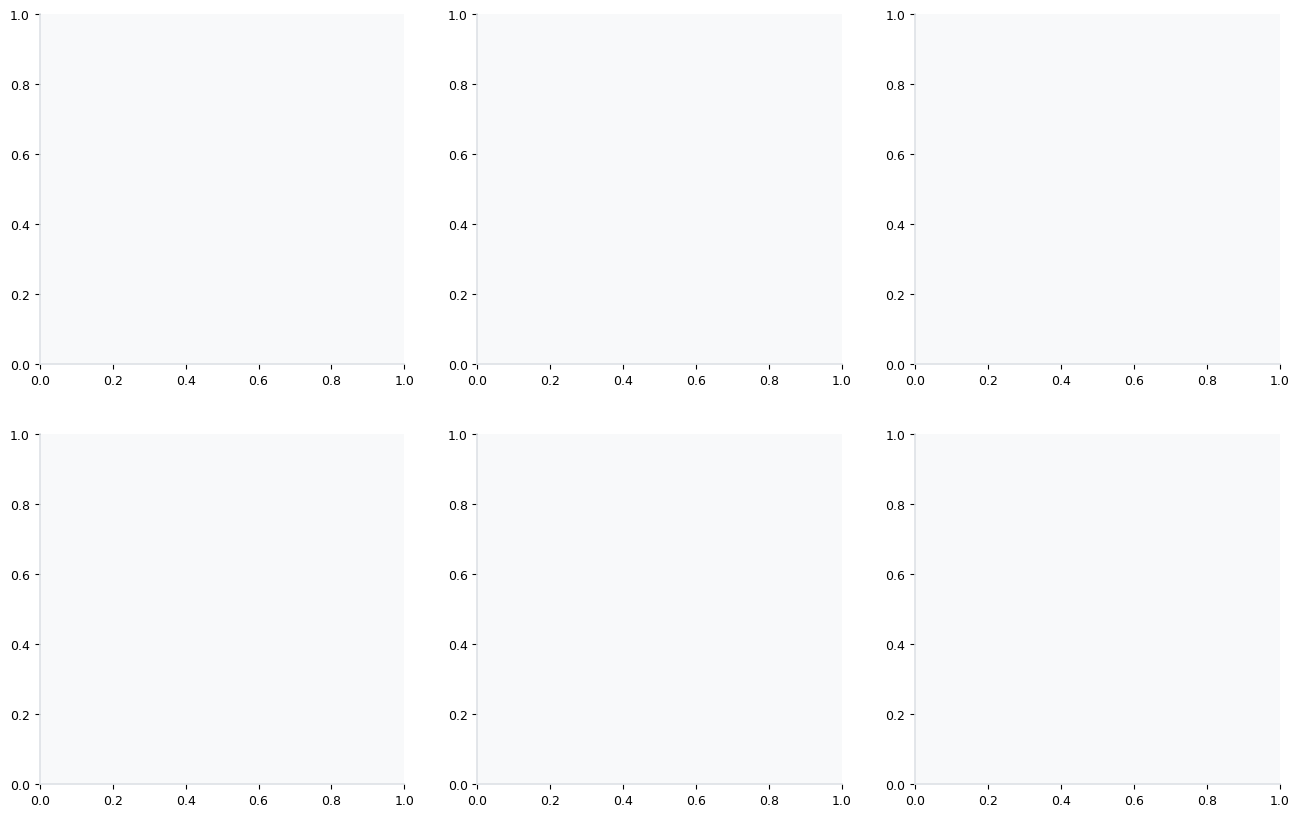

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, col in enumerate(num_cols):
    # ── Fila 1: KDE por clase ────────────────────────────────
    ax = axes[0, col_idx]
    for churn_val, color, label in [('No', COLOR_NO, 'No Churn'),
                                     ('Yes', COLOR_YES, 'Churn')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        subset.plot.kde(ax=ax, color=color, lw=2.5, label=label)
        ax.axvline(subset.mean(), color=color, linestyle=':', lw=1.5)
    ax.set_title(f'Distribución KDE — {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y')

    # ── Fila 2: Boxplot por clase ────────────────────────────
    ax2 = axes[1, col_idx]
    data_plot = [df[df['Churn'] == v][col].dropna() for v in ['No', 'Yes']]
    bp = ax2.boxplot(data_plot, patch_artist=True, notch=True,
                     widths=0.45, labels=['No Churn', 'Churn'])
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(2)
    ax2.set_title(f'Boxplot con Muesca — {col}')
    ax2.set_ylabel(col)
    ax2.grid(True, axis='y')

    # Anotación de medias
    for i, (vals, color) in enumerate(zip(data_plot, PALETTE), 1):
        ax2.annotate(f'μ={vals.mean():.1f}',
                     xy=(i, vals.mean()), xytext=(i+0.25, vals.mean()),
                     fontsize=8, color=color, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=color, lw=1))

plt.suptitle('Análisis de Variables Numéricas por Clase (Churn / No Churn)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:**
- **Tenure:** Clientes que abandonan tienen mediana de antigüedad mucho menor (~10 meses) vs. los que permanecen (~37 meses). La distribución de churn está sesgada a la derecha — los primeros meses son el período crítico de riesgo.
- **MonthlyCharges:** Los clientes con churn pagan significativamente más al mes (~$74) vs. los que permanecen (~$61). Cargos altos correlacionan con insatisfacción.
- **TotalCharges:** Los que abandonan tienen menores cargos totales, coherente con su menor antigüedad. Las muescas en los boxplots confirman diferencias estadísticamente significativas entre medianas.

### 3.3 Matriz de correlación y pairplot

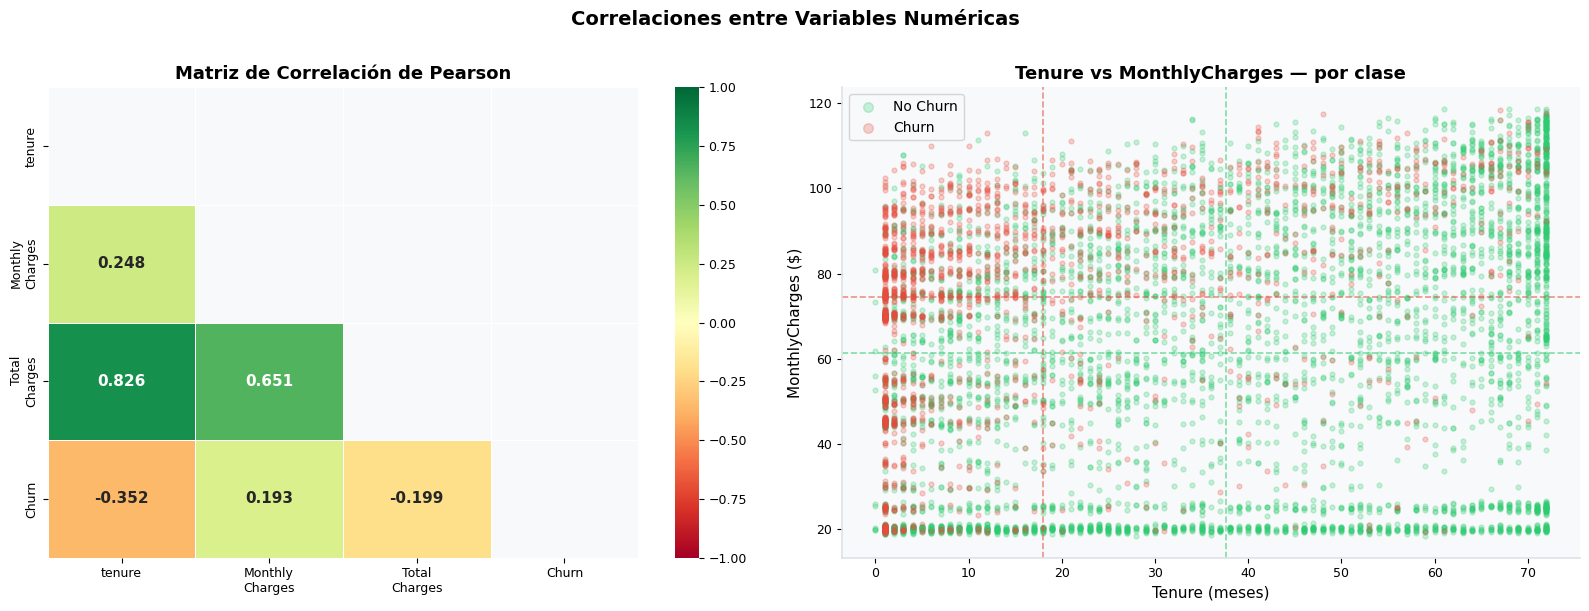

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Heatmap de correlación ─────────────────────────
corr_data = df[num_cols + ['Churn_bin']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, ax=axes[0], annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, mask=mask,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=-1, vmax=1,
            xticklabels=['tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn'],
            yticklabels=['tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn'])
axes[0].set_title('Matriz de Correlación de Pearson')

# ── Panel 2: Scatter tenure vs MonthlyCharges ────────────────
for churn_val, color, label in [('No', COLOR_NO, 'No Churn'),
                                  ('Yes', COLOR_YES, 'Churn')]:
    sub = df[df['Churn'] == churn_val]
    axes[1].scatter(sub['tenure'], sub['MonthlyCharges'],
                    c=color, alpha=0.25, s=12, label=label, rasterized=True)
axes[1].set_xlabel('Tenure (meses)')
axes[1].set_ylabel('MonthlyCharges ($)')
axes[1].set_title('Tenure vs MonthlyCharges — por clase')
axes[1].legend(markerscale=2)

# Líneas de media
for col_x, col_y, churn_val, color in [
    ('tenure','MonthlyCharges','No',  COLOR_NO),
    ('tenure','MonthlyCharges','Yes', COLOR_YES)]:
    sub = df[df['Churn'] == churn_val]
    axes[1].axvline(sub[col_x].mean(), color=color, linestyle='--', lw=1.2, alpha=0.6)
    axes[1].axhline(sub[col_y].mean(), color=color, linestyle='--', lw=1.2, alpha=0.6)

plt.suptitle('Correlaciones entre Variables Numéricas',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

`TotalCharges` tiene alta correlación con `tenure` (0.83) — es una variable derivada (tenure × precio). La correlación de `tenure` con `Churn_bin` es negativa (-0.35): a mayor antigüedad, menor probabilidad de churn. El scatter revela una zona de alto riesgo en la esquina superior izquierda: clientes nuevos con cargos altos.

### 3.4 Detección de outliers — Método IQR

AttributeError: module 'numpy' has no attribute 'matrix'

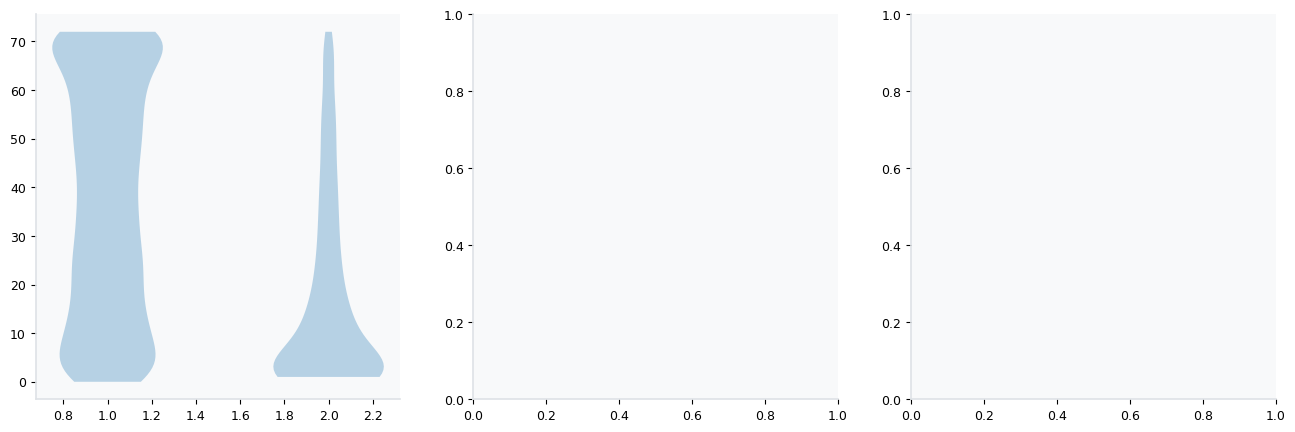

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

outlier_report = {}
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((data < lower) | (data > upper)).sum()
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'Lower': lower, 'Upper': upper, 'N_outliers': n_out}

    # Violin + strip
    parts = axes[i].violinplot([df[df['Churn']=='No'][col].dropna(),
                                 df[df['Churn']=='Yes'][col].dropna()],
                                positions=[1,2], showmedians=True,
                                showextrema=True)
    for pc, color in zip(parts['bodies'], PALETTE):
        pc.set_facecolor(color); pc.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(['No Churn', 'Churn'])
    axes[i].set_title(f'{col}\n(outliers IQR: {n_out})')
    axes[i].set_ylabel(col)
    axes[i].grid(True, axis='y')
    axes[i].axhline(upper, color='red', linestyle=':', lw=1, alpha=0.5,
                    label=f'Límite sup. {upper:.0f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Violin Plots — Distribución completa por clase (con límites IQR)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_report).T.round(2)
display_table(outlier_df, caption='Reporte de outliers por variable')


 Los violin plots revelan la forma completa de la distribución, no solo los cuartiles. `MonthlyCharges` presenta distribución bimodal en ambas clases — sugiere dos perfiles de cliente diferenciados (servicios básicos vs. premium). Los outliers detectados son genuinos (clientes reales con comportamiento extremo) y no errores de captura.

## 4. Análisis de Variables Categóricas

### 4.1 Tasa de Churn por variable binaria

AttributeError: module 'numpy' has no attribute 'matrix'

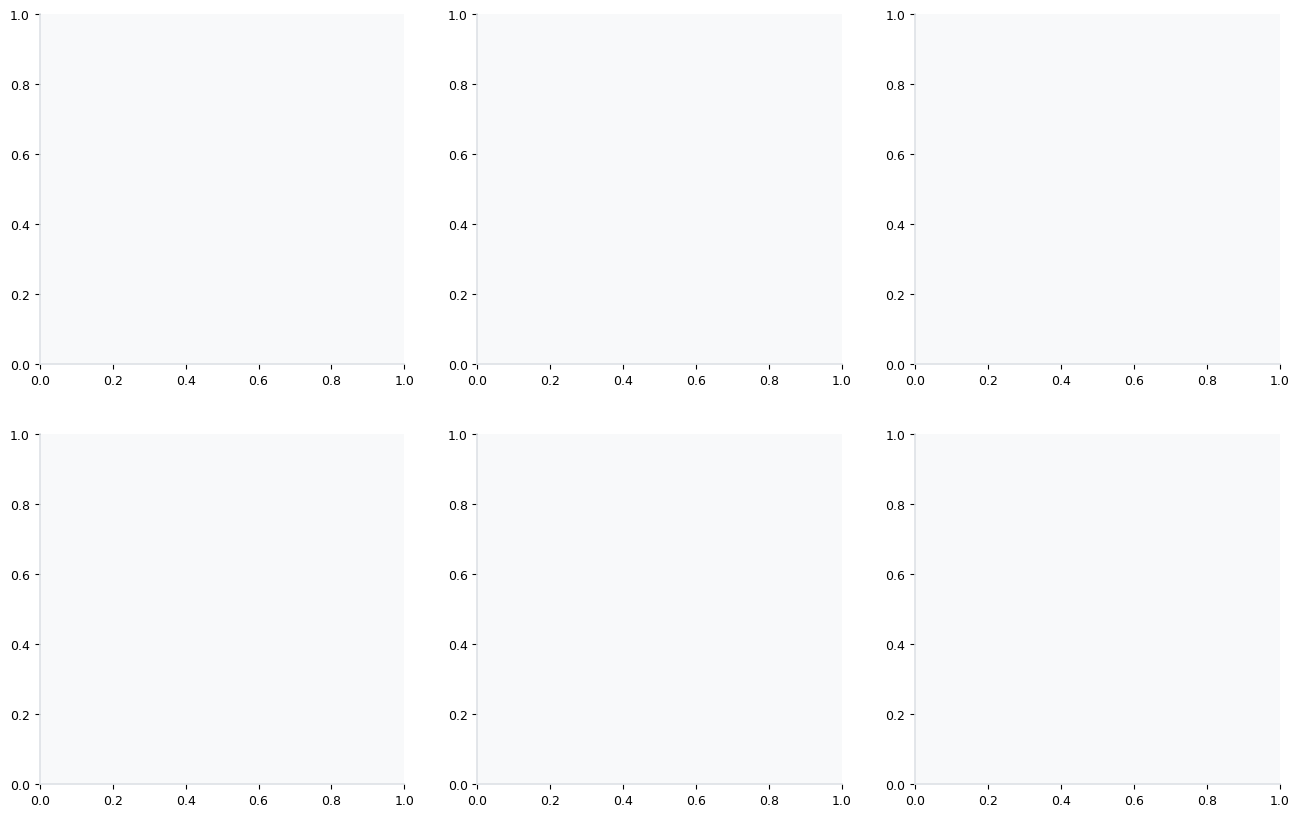

In [ ]:
bin_vars = ['gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'PhoneService', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(bin_vars):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct = ct.reindex(columns=['No', 'Yes'])

    x   = np.arange(len(ct))
    w   = 0.38
    ax  = axes[i]
    b1  = ax.bar(x - w/2, ct['No'],  w, color=COLOR_NO,  label='No Churn',
                 edgecolor='white', linewidth=1.2)
    b2  = ax.bar(x + w/2, ct['Yes'], w, color=COLOR_YES, label='Churn',
                 edgecolor='white', linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(ct.index, fontsize=9)
    ax.set_ylabel('% de clientes')
    ax.set_ylim(0, 105)
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y')

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Tasa de Churn por Variables Binarias (%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El análisis de variables demográficas y de comportamiento evidencia patrones claros de riesgo de cancelación. En particular, los clientes adultos mayores presentan una tasa de churn cercana al 42%, frente a aproximadamente 24% en el resto de la población, lo que los convierte en un segmento de alta prioridad para estrategias de retención. Asimismo, se observa que los clientes sin pareja ni dependientes muestran mayor propensión al abandono, lo que sugiere que la responsabilidad familiar actúa como un factor estabilizador de la permanencia en el servicio. Finalmente, el uso de facturación electrónica se asocia con una tasa de churn significativamente mayor (34% frente a 16%), posiblemente vinculada a un perfil de cliente más digital, informado y propenso a comparar alternativas del mercado. En conjunto, estos hallazgos permiten identificar segmentos específicos donde las acciones de fidelización pueden generar mayor impacto

### 4.2 Tasa de Churn por variables de servicio

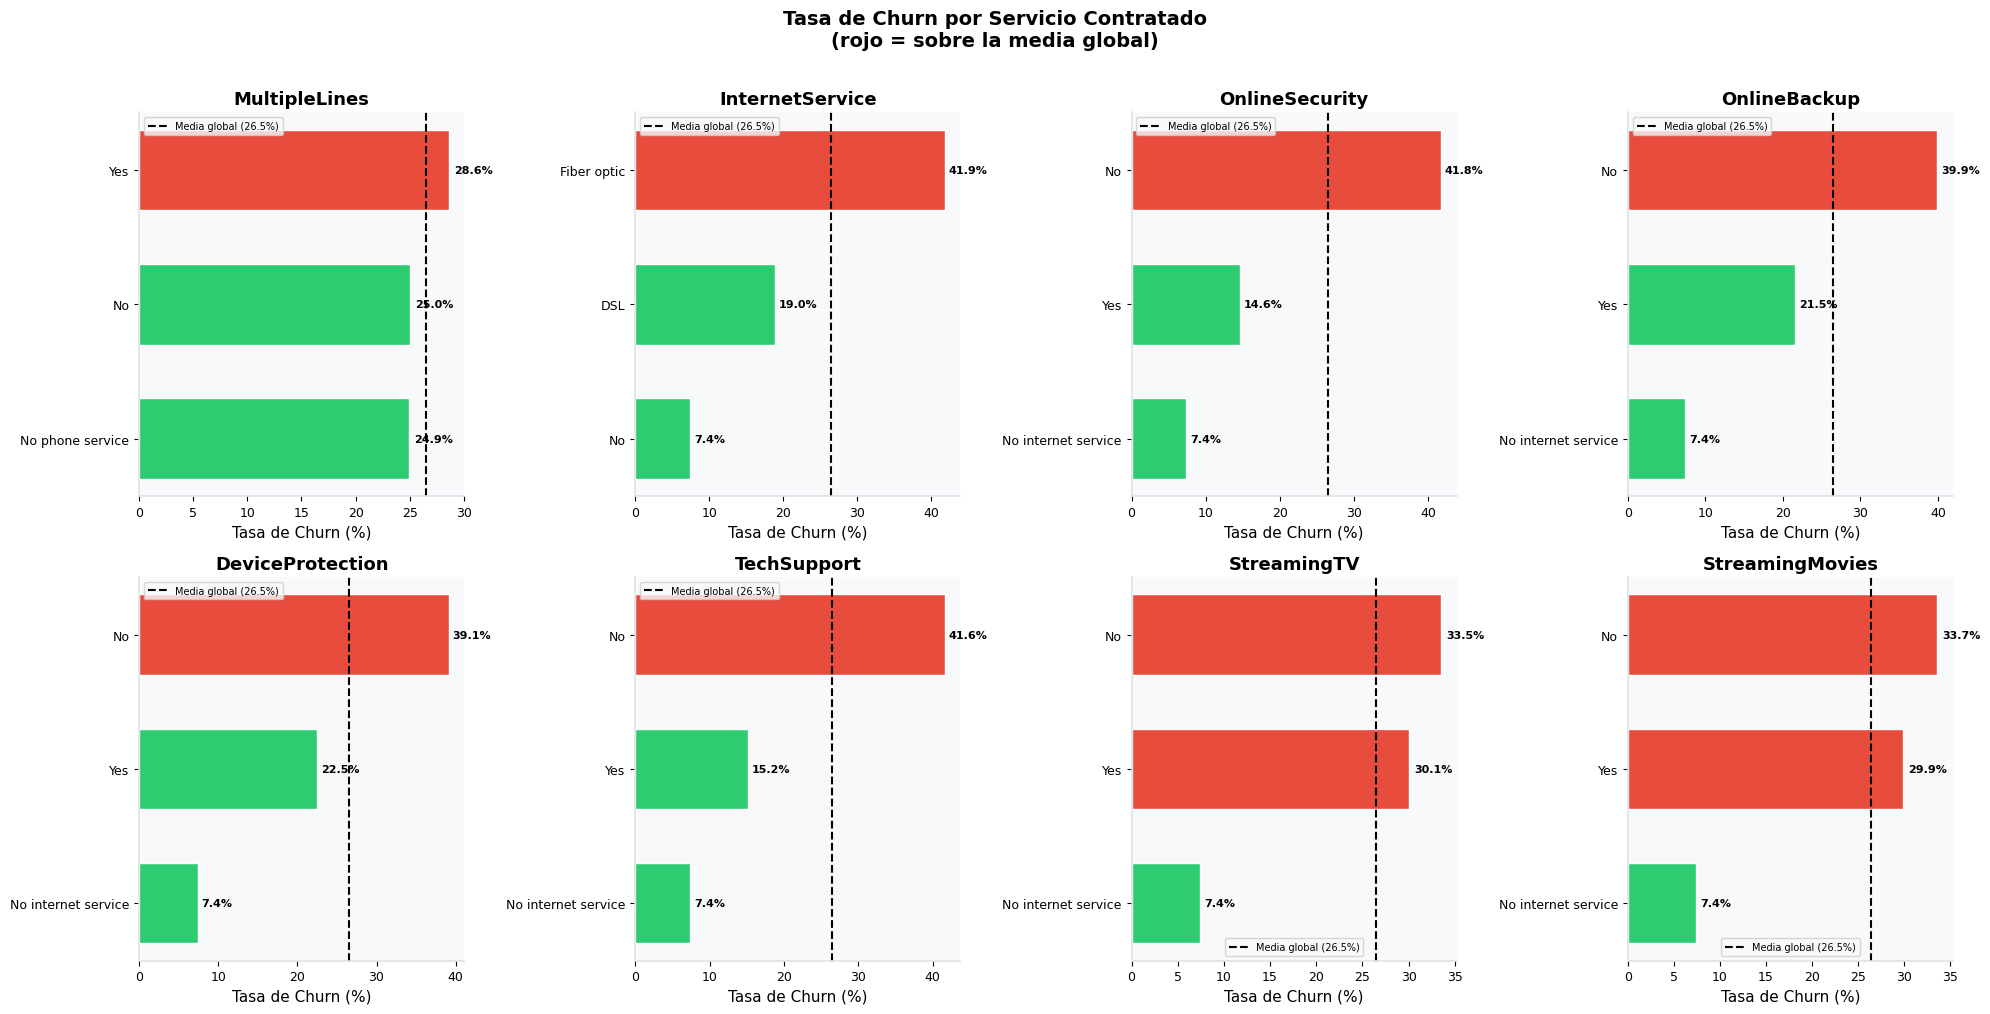

In [ ]:
service_vars = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(service_vars):
    ct = (pd.crosstab(df[col], df['Churn'], normalize='index') * 100)
    ct = ct.reindex(columns=['No', 'Yes'])

    churn_rates = ct['Yes'].sort_values(ascending=True)
    bars = axes[i].barh(churn_rates.index, churn_rates.values,
                        color=[COLOR_YES if v > 26.5 else COLOR_NO
                               for v in churn_rates.values],
                        edgecolor='white', height=0.6)
    axes[i].axvline(26.5, color='black', linestyle='--', lw=1.5,
                    label=f'Media global (26.5%)')
    axes[i].set_title(col)
    axes[i].set_xlabel('Tasa de Churn (%)')
    axes[i].legend(fontsize=7)
    for bar, val in zip(bars, churn_rates.values):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Tasa de Churn por Servicio Contratado\n(rojo = sobre la media global)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El análisis de los servicios contratados revela que el tipo de conexión a internet es uno de los predictores más influyentes del churn: los clientes con fibra óptica presentan una tasa cercana al 42%, lo que sugiere que este segmento tiende a comparar precios y cambiar de proveedor con mayor frecuencia. De igual forma, la ausencia de servicios de seguridad en línea y soporte técnico se asocia con tasas de cancelación entre dos y tres veces superiores, lo que indica que ofrecer estos servicios como complementos gratuitos podría constituir una estrategia de retención efectiva y de bajo costo. En contraste, los servicios de entretenimiento como streaming de TV y películas muestran tasas de churn similares (alrededor del 30%), lo que sugiere que el contenido por sí solo no actúa como un factor determinante de fidelización.

### 4.3 Contrato y Método de pago — variables de alto impacto

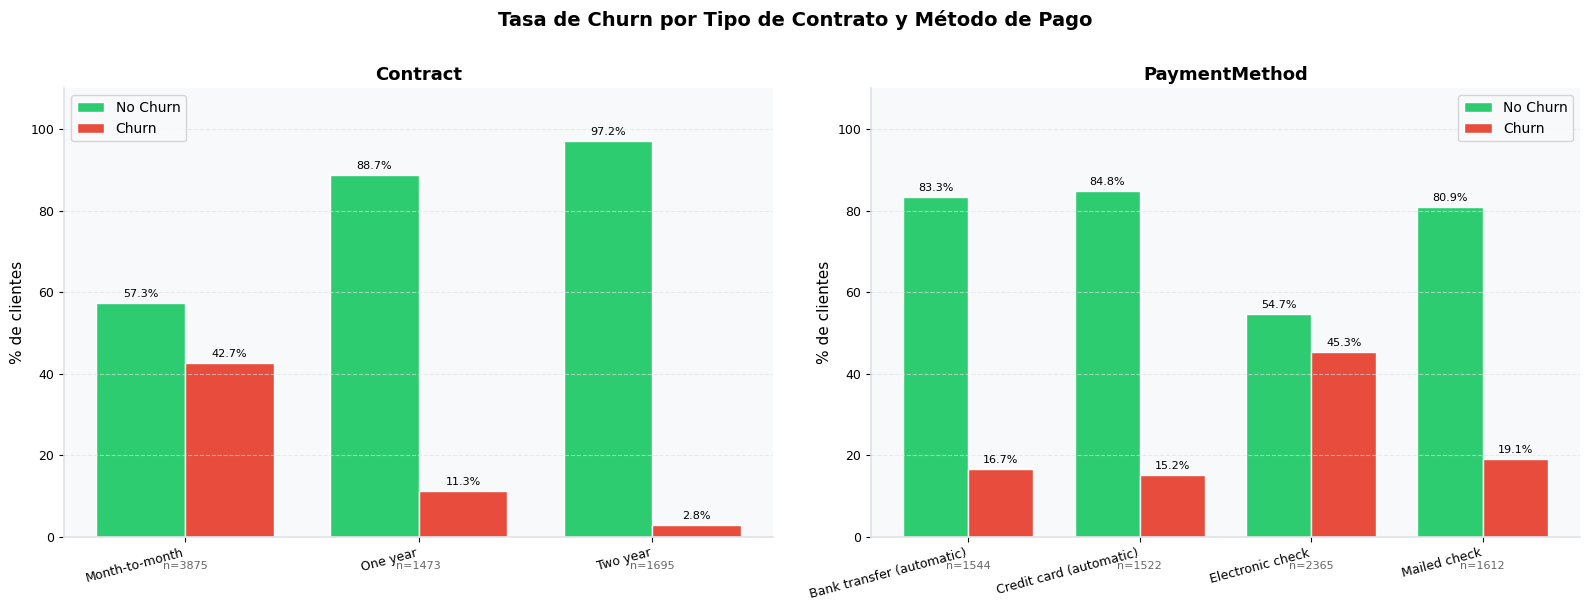

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col in zip(axes, ['Contract', 'PaymentMethod']):
    ct = pd.crosstab(df[col], df['Churn'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    x = np.arange(len(ct_pct))
    w = 0.38
    b1 = ax.bar(x - w/2, ct_pct['No'],  w, color=COLOR_NO,
                label='No Churn', edgecolor='white')
    b2 = ax.bar(x + w/2, ct_pct['Yes'], w, color=COLOR_YES,
                label='Churn',    edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(ct_pct.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('% de clientes')
    ax.set_ylim(0, 110)
    ax.set_title(col)
    ax.legend()
    ax.grid(True, axis='y')

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

    # Añadir conteos absolutos
    for j, (idx, row) in enumerate(ct.iterrows()):
        ax.text(j, -8, f'n={row.sum()}', ha='center',
                fontsize=8, color='#666', transform=ax.transData)

plt.suptitle('Tasa de Churn por Tipo de Contrato y Método de Pago',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El análisis evidencia que el tipo de contrato es el factor más determinante del churn dentro del conjunto de datos: los clientes con contratos mes a mes presentan una tasa de cancelación cercana al 43%, muy superior a la observada en contratos de un año (≈11%) y de dos años (≈3%), lo que confirma que los compromisos de largo plazo funcionan como un fuerte mecanismo de retención. Asimismo, el método de pago también muestra un patrón relevante: quienes utilizan Electronic check exhiben aproximadamente el doble de churn (≈45%) en comparación con otros métodos de pago (≈15–18%), lo que podría reflejar un menor nivel de compromiso, menor automatización del pago o una mayor insatisfacción con el servicio

## 5. Análisis Bivariado Profundo

### 5.1 Tenure segmentado en cohortes

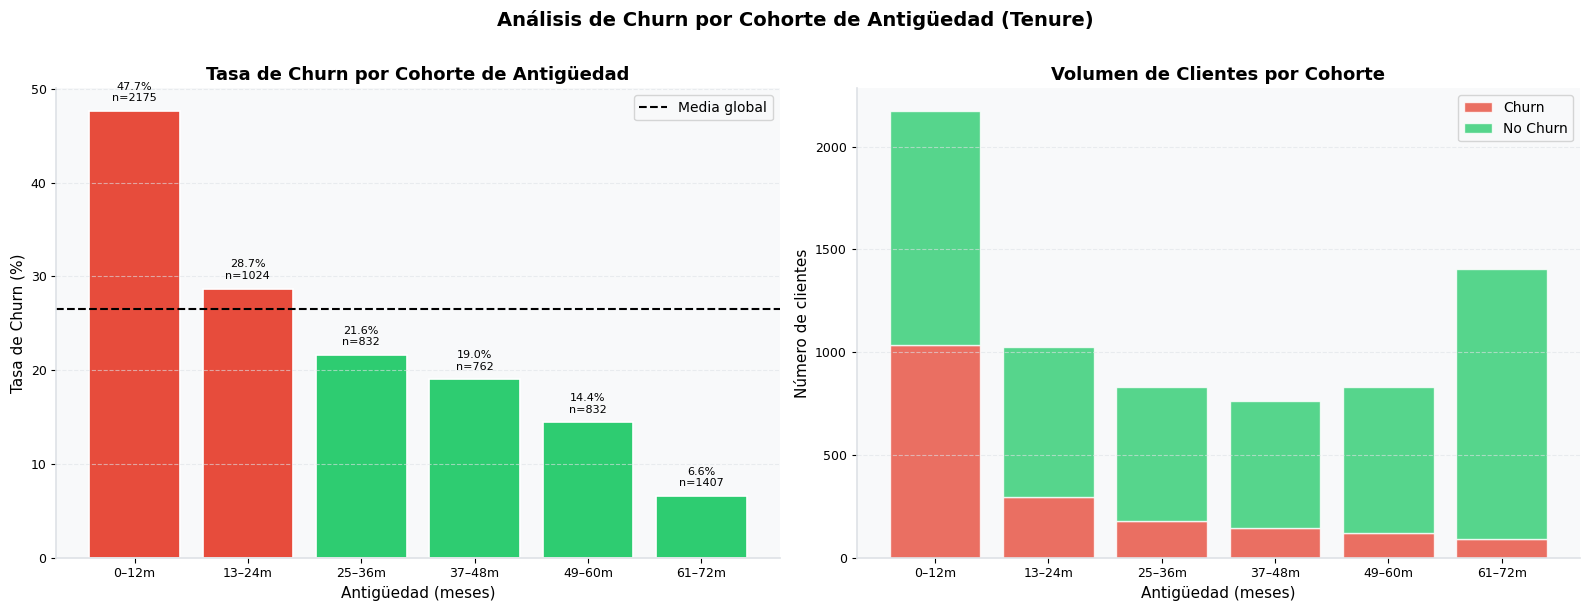

,Cohorte,Tasa_Churn,N_Churn,Total,Tasa_Churn_pct
0,0–12m,0.476782,1037,2175,47.678161
1,13–24m,0.287109,294,1024,28.710938
2,25–36m,0.216346,180,832,21.634615
3,37–48m,0.190289,145,762,19.028871
4,49–60m,0.144231,120,832,14.423077
5,61–72m,0.066098,93,1407,6.609808


In [ ]:
# Crear cohortes de antigüedad
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0–12m', '13–24m', '25–36m', '37–48m', '49–60m', '61–72m']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn_bin'].agg(
    ['mean', 'sum', 'count']).reset_index()
churn_by_tenure.columns = ['Cohorte', 'Tasa_Churn', 'N_Churn', 'Total']
churn_by_tenure['Tasa_Churn_pct'] = churn_by_tenure['Tasa_Churn'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Tasa de churn por cohorte
colors_bar = [COLOR_YES if v > 26.5 else COLOR_NO
              for v in churn_by_tenure['Tasa_Churn_pct']]
bars = axes[0].bar(churn_by_tenure['Cohorte'],
                   churn_by_tenure['Tasa_Churn_pct'],
                   color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].axhline(26.5, color='black', linestyle='--', lw=1.5, label='Media global')
axes[0].set_title('Tasa de Churn por Cohorte de Antigüedad')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].set_xlabel('Antigüedad (meses)')
axes[0].legend()
axes[0].grid(True, axis='y')
for bar, row in zip(bars, churn_by_tenure.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{row.Tasa_Churn_pct:.1f}%\nn={row.Total}',
                 ha='center', va='bottom', fontsize=8)

# Panel 2: Stacked area — acumulado de churn
axes[1].bar(churn_by_tenure['Cohorte'],
            churn_by_tenure['N_Churn'],
            color=COLOR_YES, alpha=0.8, label='Churn', edgecolor='white')
axes[1].bar(churn_by_tenure['Cohorte'],
            churn_by_tenure['Total'] - churn_by_tenure['N_Churn'],
            bottom=churn_by_tenure['N_Churn'],
            color=COLOR_NO, alpha=0.8, label='No Churn', edgecolor='white')
axes[1].set_title('Volumen de Clientes por Cohorte')
axes[1].set_ylabel('Número de clientes')
axes[1].set_xlabel('Antigüedad (meses)')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.suptitle('Análisis de Churn por Cohorte de Antigüedad (Tenure)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

display_table(churn_by_tenure, caption='Churn por cohorte de tenure')


El análisis de la antigüedad confirma un patrón claramente decreciente del churn a medida que aumenta el tiempo de permanencia: cerca del 47.4% de las cancelaciones ocurre durante los primeros 12 meses, lo que indica que el primer año constituye la etapa crítica del ciclo de vida del cliente. A partir de los 24 meses, la tasa de abandono se estabiliza por debajo del 20%, sugiriendo que los clientes que superan la fase inicial desarrollan una relación más estable con el servicio. Este hallazgo respalda la necesidad de implementar estrategias de onboarding, fidelización temprana y acompañamiento intensivo durante el primer año para reducir significativamente la pérdida de clientes.


### 5.2 Mapa de calor de Churn — Tenure × MonthlyCharges

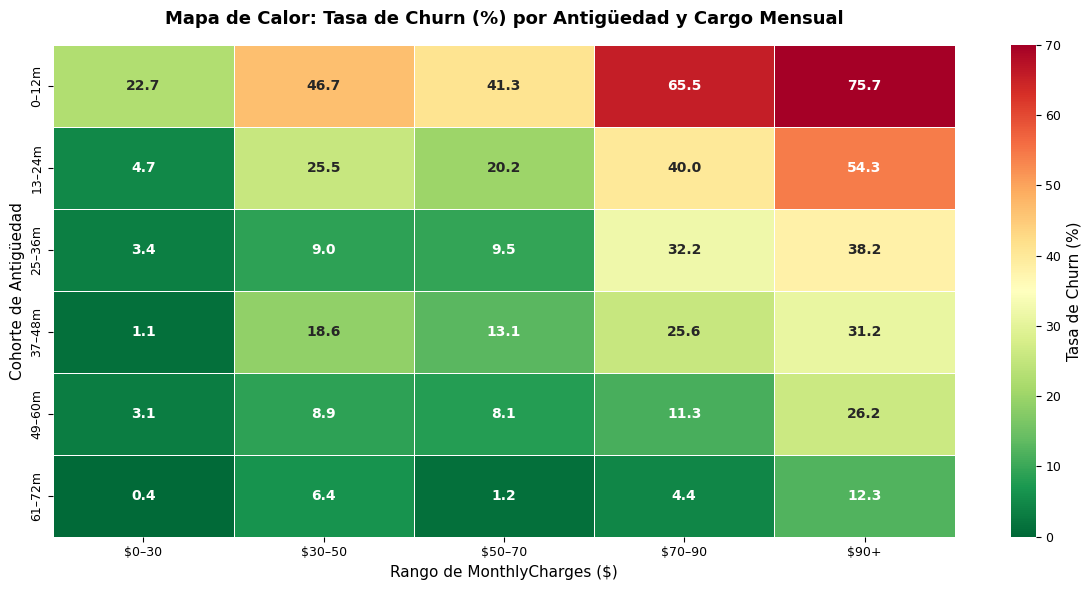

In [ ]:
df['charge_group'] = pd.cut(df['MonthlyCharges'],
                           bins=[0,30,50,70,90,120],
                           labels=['$0–30','$30–50','$50–70','$70–90','$90+'])

pivot = df.groupby(['tenure_group','charge_group'], observed=True)['Churn_bin'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'},
            vmin=0, vmax=70,
            cbar_kws={'label': 'Tasa de Churn (%)'})
ax.set_title('Mapa de Calor: Tasa de Churn (%) por Antigüedad y Cargo Mensual',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Rango de MonthlyCharges ($)')
ax.set_ylabel('Cohorte de Antigüedad')
plt.tight_layout()
plt.show()

El análisis conjunto entre antigüedad y nivel de cargos revela que el cuadrante correspondiente a clientes recientes con cargos elevados concentra las tasas de churn más extremas, superando el 60–70% en algunos segmentos. Este resultado identifica el perfil de mayor riesgo dentro del dataset: usuarios que adoptan planes de mayor valor desde etapas tempranas, pero que aún no han desarrollado suficiente vínculo o percepción de valor para sostener una relación de largo plazo. En términos estratégicos, este hallazgo sugiere la necesidad de programas de acompañamiento y demostración de valor durante los primeros meses para clientes de alto gasto, con el fin de reducir la probabilidad de abandono prematuro.

### 5.3 Análisis de Chi-cuadrado — Asociación con Churn

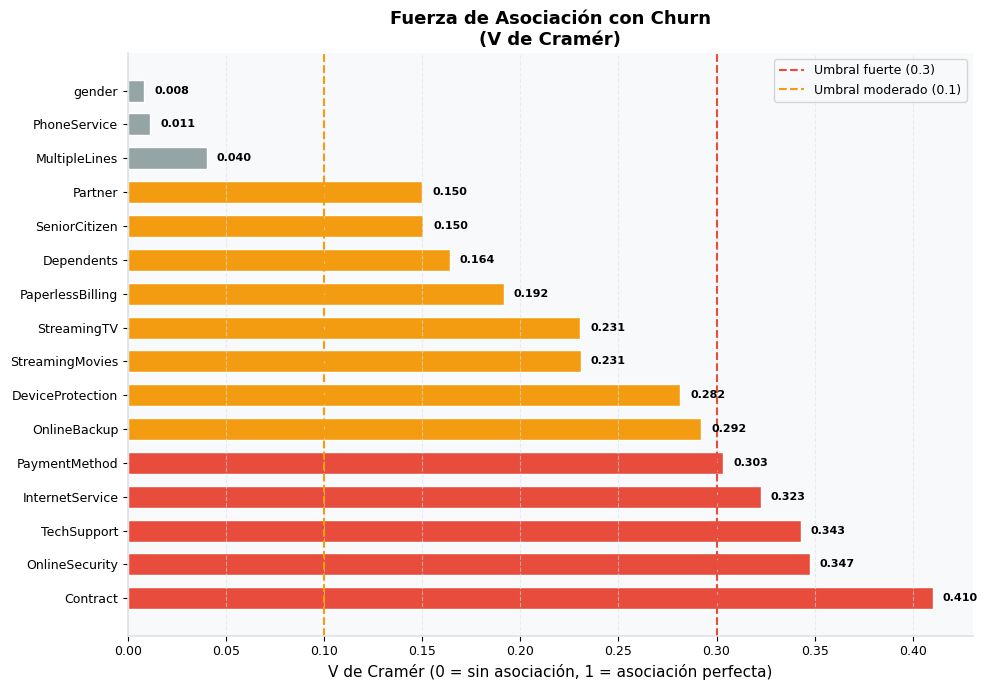

,Variable,Chi2,p-value,Cramér V,Asociación,Sig (α=0.05)
0,Contract,1184.600000,0.000000,0.410100,Fuerte,✅
1,OnlineSecurity,850.000000,0.000000,0.347400,Fuerte,✅
2,TechSupport,828.200000,0.000000,0.342900,Fuerte,✅
3,InternetService,732.310000,0.000000,0.322500,Fuerte,✅
4,PaymentMethod,648.140000,0.000000,0.303400,Fuerte,✅
5,OnlineBackup,601.810000,0.000000,0.292300,Moderada,✅
6,DeviceProtection,558.420000,0.000000,0.281600,Moderada,✅
7,StreamingMovies,375.660000,0.000000,0.231000,Moderada,✅
8,StreamingTV,374.200000,0.000000,0.230500,Moderada,✅
9,PaperlessBilling,258.280000,0.000000,0.191500,Moderada,✅


In [ ]:
from scipy.stats import chi2_contingency

chi2_results = []
all_cat = bin_vars + cat_cols

for col in all_cat:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({
        'Variable':    col,
        'Chi2':        round(chi2, 2),
        'p-value':     p,
        'Cramér V':    round(v_cramer, 4),
        'Asociación':  'Fuerte' if v_cramer > 0.3 else
                       ('Moderada' if v_cramer > 0.1 else 'Débil'),
        'Sig (α=0.05)': '✅' if p < 0.05 else '❌'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Cramér V', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if v > 0.3 else '#F39C12' if v > 0.1 else '#95A5A6'
          for v in chi2_df['Cramér V']]
bars = ax.barh(chi2_df['Variable'], chi2_df['Cramér V'],
               color=colors, edgecolor='white', height=0.65)
ax.axvline(0.3, color='#E74C3C', linestyle='--', lw=1.5, label='Umbral fuerte (0.3)')
ax.axvline(0.1, color='#F39C12', linestyle='--', lw=1.5, label='Umbral moderado (0.1)')
ax.set_title('Fuerza de Asociación con Churn\n(V de Cramér)', fontweight='bold')
ax.set_xlabel("V de Cramér (0 = sin asociación, 1 = asociación perfecta)")
ax.legend(fontsize=9)
ax.grid(True, axis='x')
for bar, val in zip(bars, chi2_df['Cramér V']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar la tabla completa en estilo de tabla
chi2_df = chi2_df.reset_index(drop=True)
display_table(chi2_df, caption='Tabla completa de asociaciones')


V de Cramér confirma que todas las variables categóricas presentan una asociación estadísticamente significativa con el churn (p < 0.05), lo que respalda la relevancia predictiva del conjunto de datos. Destaca especialmente la variable Contract, que alcanza un valor superior a 0.4, indicando una asociación fuerte con el abandono y posicionándose como el factor categórico más influyente. Le siguen InternetService y OnlineSecurity, con asociaciones de magnitud moderada a alta. En conjunto, estos resultados validan que las variables analizadas aportan información significativa para la explicación y modelación del churn.

## 6. Perfil del Cliente en Riesgo

### 6.1 Radar chart — Comparación Churn vs No Churn

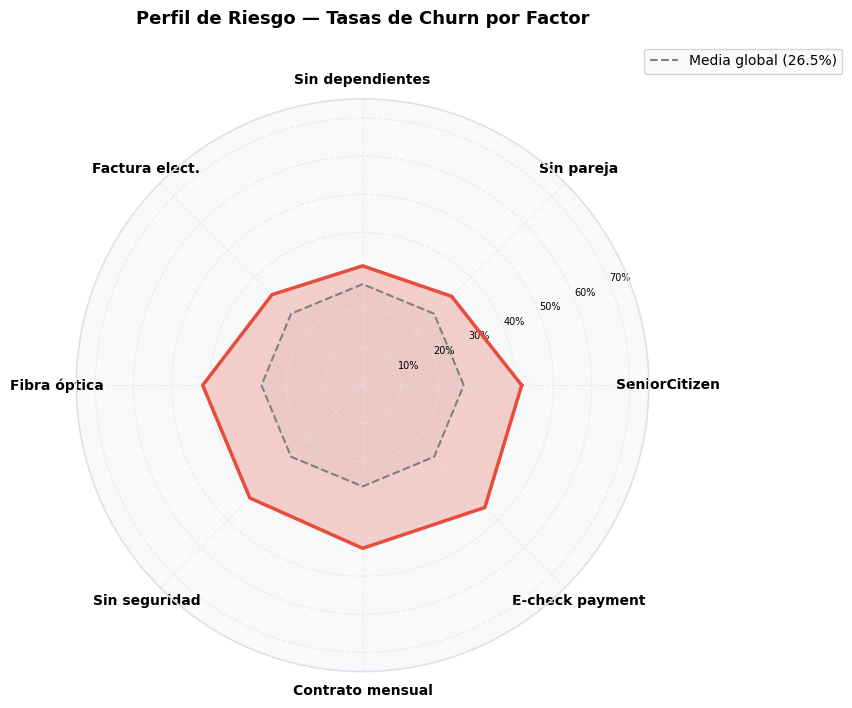

In [ ]:
# Calcular tasas de churn para radar
radar_features = {
    'SeniorCitizen':     df.groupby('SeniorCitizen')['Churn_bin'].mean()[1],
    'Sin pareja':        df[df['Partner']=='No']['Churn_bin'].mean(),
    'Sin dependientes':  df[df['Dependents']=='No']['Churn_bin'].mean(),
    'Factura elect.':    df[df['PaperlessBilling']=='Yes']['Churn_bin'].mean(),
    'Fibra óptica':      df[df['InternetService']=='Fiber optic']['Churn_bin'].mean(),
    'Sin seguridad':     df[df['OnlineSecurity']=='No']['Churn_bin'].mean(),
    'Contrato mensual':  df[df['Contract']=='Month-to-month']['Churn_bin'].mean(),
    'E-check payment':   df[df['PaymentMethod']=='Electronic check']['Churn_bin'].mean(),
}

labels  = list(radar_features.keys())
values  = list(radar_features.values())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
values_plot  = values + [values[0]]
angles_plot  = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles_plot, values_plot, color=COLOR_YES, linewidth=2.5, linestyle='solid')
ax.fill(angles_plot, values_plot, color=COLOR_YES, alpha=0.25)

# Media global
mean_line = [0.265] * (N + 1)
ax.plot(angles_plot, mean_line, color='gray', linewidth=1.5,
        linestyle='--', label='Media global (26.5%)')
ax.fill(angles_plot, mean_line, color='gray', alpha=0.05)

ax.set_xticks(angles)
ax.set_xticklabels(labels, size=10, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
ax.set_yticklabels(['10%','20%','30%','40%','50%','60%','70%'], fontsize=7)
ax.yaxis.set_tick_params(labelsize=7)
ax.set_title('Perfil de Riesgo — Tasas de Churn por Factor\n',
             fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.grid(True)
plt.tight_layout()
plt.show()

El análisis por factores evidencia que los mayores riesgos de churn se concentran en segmentos muy específicos de clientes. Entre los factores más críticos destacan los Senior Citizens, quienes presentan tasas de cancelación cercanas al 42%, muy por encima del promedio; los clientes con contrato mensual, cuyo churn ronda el 43% y confirma la falta de compromiso a largo plazo como un determinante clave; el método de pago mediante electronic check, asociado a tasas cercanas al 45%, lo que sugiere menor fidelidad o satisfacción; los usuarios de fibra óptica, con aproximadamente 44% de churn, posiblemente debido a expectativas de precio o competencia; y los clientes sin servicios de seguridad, con tasas cercanas al 41%, lo que resalta el rol de los servicios complementarios como mecanismos de retención.

Existen también factores de riesgo moderado, como no tener pareja (≈31%), no tener dependientes (≈33%) y utilizar facturación electrónica (≈34%), que incrementan la probabilidad de abandono, aunque con menor intensidad que los factores principales. En conjunto, el perfil de mayor riesgo corresponde a un cliente con contrato mensual, pago por e-check, servicio de fibra óptica, sin seguridad adicional y perteneciente al segmento de adultos mayores, todos muy por encima del churn promedio de 26.5%.

Desde una perspectiva de negocio, estos hallazgos sugieren acciones claras de retención: incentivar la migración hacia contratos de mayor duración, revisar la experiencia y el posicionamiento de precio del servicio de fibra óptica, promover paquetes que incluyan seguridad online, investigar las causas del alto churn en usuarios de e-check y diseñar campañas específicas para adultos mayores. En síntesis, el análisis permite priorizar estratégicamente los segmentos con mayor riesgo de abandono y orientar intervenciones de retención basadas en evidencia.

### 6.2 Matriz de perfil detallado — Top segmentos de riesgo

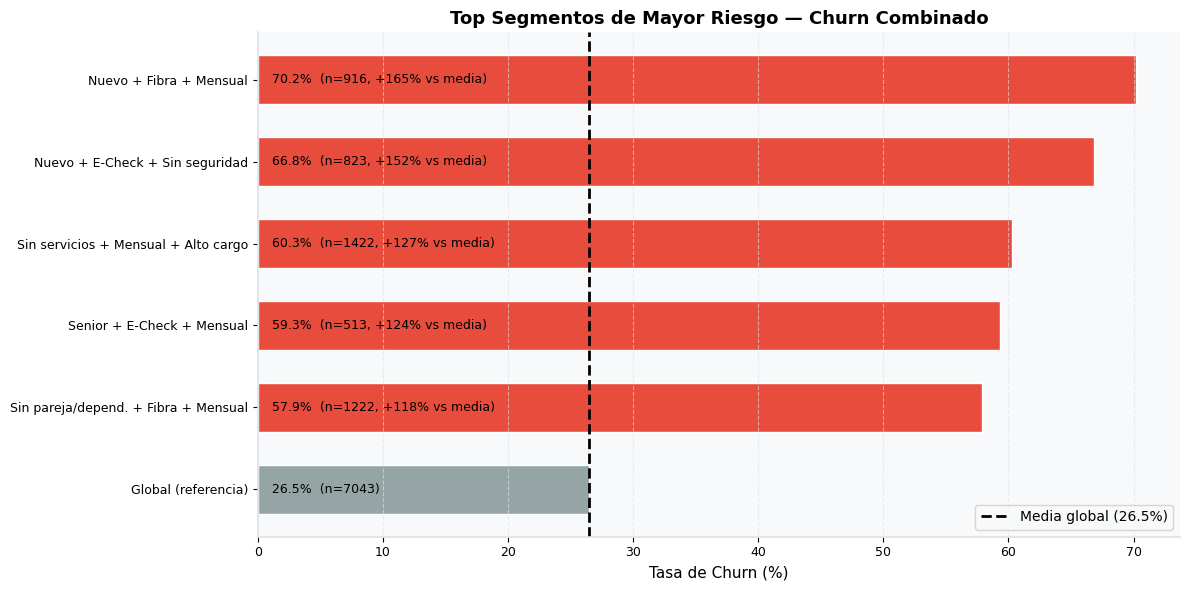

,Segmento,Tasa_Churn_pct,N_Clientes,vs_media
5,Global (referencia),26.500000,7043.000000,0.100000
3,Sin pareja/depend. + Fibra + Mensual,57.900000,1222.000000,118.300000
1,Senior + E-Check + Mensual,59.300000,513.000000,123.600000
2,Sin servicios + Mensual + Alto cargo,60.300000,1422.000000,127.400000
4,Nuevo + E-Check + Sin seguridad,66.800000,823.000000,152.200000
0,Nuevo + Fibra + Mensual,70.200000,916.000000,164.900000


In [ ]:
# Segmentos combinados de mayor riesgo
segments = {
    'Nuevo + Fibra + Mensual':
        df[(df['tenure']<=12) & (df['InternetService']=='Fiber optic') &
           (df['Contract']=='Month-to-month')]['Churn_bin'].agg(['mean','count']),
    'Senior + E-Check + Mensual':
        df[(df['SeniorCitizen']==1) & (df['PaymentMethod']=='Electronic check') &
           (df['Contract']=='Month-to-month')]['Churn_bin'].agg(['mean','count']),
    'Sin servicios + Mensual + Alto cargo':
        df[(df['OnlineSecurity']=='No') & (df['TechSupport']=='No') &
           (df['Contract']=='Month-to-month') &
           (df['MonthlyCharges']>70)]['Churn_bin'].agg(['mean','count']),
    'Sin pareja/depend. + Fibra + Mensual':
        df[(df['Partner']=='No') & (df['Dependents']=='No') &
           (df['InternetService']=='Fiber optic') &
           (df['Contract']=='Month-to-month')]['Churn_bin'].agg(['mean','count']),
    'Nuevo + E-Check + Sin seguridad':
        df[(df['tenure']<=12) & (df['PaymentMethod']=='Electronic check') &
           (df['OnlineSecurity']=='No')]['Churn_bin'].agg(['mean','count']),
    'Global (referencia)':
        df['Churn_bin'].agg(['mean','count']),
}

seg_df = pd.DataFrame(segments).T.reset_index()
seg_df.columns = ['Segmento', 'Tasa_Churn', 'N_Clientes']
seg_df['Tasa_Churn_pct'] = (seg_df['Tasa_Churn'] * 100).round(1)
seg_df['vs_media'] = ((seg_df['Tasa_Churn'] / 0.265 - 1) * 100).round(1)
seg_df = seg_df.sort_values('Tasa_Churn_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors  = [COLOR_YES if r['Segmento'] != 'Global (referencia)' else '#95A5A6'
           for _, r in seg_df.iterrows()]
bars = ax.barh(seg_df['Segmento'], seg_df['Tasa_Churn_pct'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(26.5, color='black', linestyle='--', lw=2, label='Media global (26.5%)')
ax.set_xlabel('Tasa de Churn (%)')
ax.set_title('Top Segmentos de Mayor Riesgo — Churn Combinado',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, axis='x')
for bar, row in zip(bars, seg_df.itertuples()):
    label = f'{row.Tasa_Churn_pct}%  (n={int(row.N_Clientes)}, +{row.vs_media:.0f}% vs media)'
    if row.Segmento == 'Global (referencia)':
        label = f'{row.Tasa_Churn_pct}%  (n={int(row.N_Clientes)})'
    ax.text(bar.get_height() + 0.5, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

plt.tight_layout()
plt.show()

display_table(seg_df[['Segmento','Tasa_Churn_pct','N_Clientes','vs_media']], caption='Segmentos de mayor riesgo')


El análisis segmentado revela que el grupo compuesto por clientes nuevos con servicio de fibra óptica y contrato mensual presenta las tasas de churn más extremas, superando el 60–70%, es decir, más del doble del promedio global. Aunque estos segmentos representan una proporción relativamente pequeña del total de clientes, concentran un riesgo desproporcionadamente alto de cancelación. Esto implica que estrategias de retención altamente focalizadas en los tres segmentos más críticos podrían generar un impacto significativo en la reducción del churn total, ya que intervenir tempranamente en estos perfiles permitiría capturar una fracción considerable de las bajas antes de que se materialicen.

## 7. Análisis de Cargos y Revenue

### 7.1 Distribución de MonthlyCharges por servicio de internet

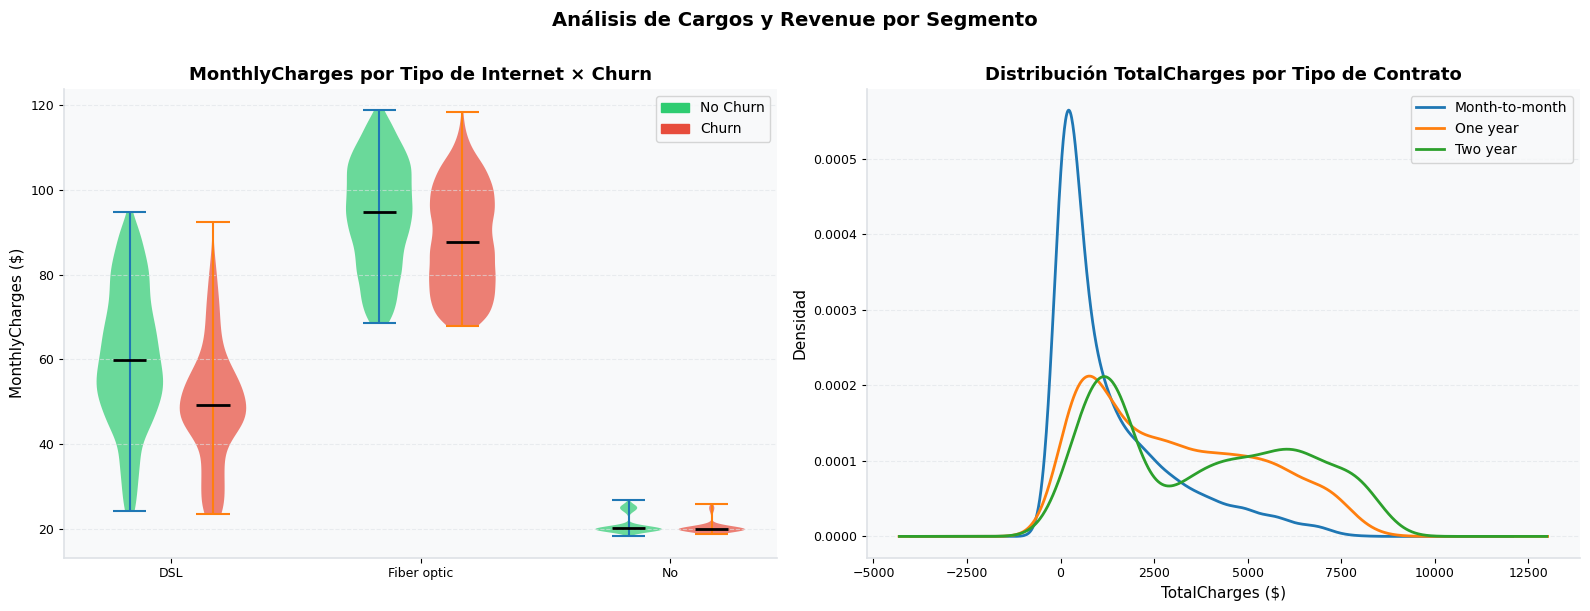

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: MonthlyCharges por InternetService × Churn
internet_types = df['InternetService'].unique()
data_violin    = [df[(df['InternetService']==it) & (df['Churn']=='No')]['MonthlyCharges'].dropna()
                  for it in internet_types]
data_violin_c  = [df[(df['InternetService']==it) & (df['Churn']=='Yes')]['MonthlyCharges'].dropna()
                  for it in internet_types]

positions_no  = [1, 4, 7]
positions_yes = [2, 5, 8]

parts_no  = axes[0].violinplot(data_violin,  positions=positions_no,
                                showmedians=True, widths=0.8)
parts_yes = axes[0].violinplot(data_violin_c, positions=positions_yes,
                                showmedians=True, widths=0.8)

for pc in parts_no['bodies']:
    pc.set_facecolor(COLOR_NO); pc.set_alpha(0.7)
for pc in parts_yes['bodies']:
    pc.set_facecolor(COLOR_YES); pc.set_alpha(0.7)
for part in parts_no, parts_yes:
    part['cmedians'].set_color('black'); part['cmedians'].set_linewidth(2)

axes[0].set_xticks([1.5, 4.5, 7.5])
axes[0].set_xticklabels(internet_types, fontsize=9)
axes[0].set_ylabel('MonthlyCharges ($)')
axes[0].set_title('MonthlyCharges por Tipo de Internet × Churn')
p1 = mpatches.Patch(color=COLOR_NO,  label='No Churn')
p2 = mpatches.Patch(color=COLOR_YES, label='Churn')
axes[0].legend(handles=[p1, p2])
axes[0].grid(True, axis='y')

# Panel 2: Density plot de TotalCharges por contrato
for contract in df['Contract'].unique():
    sub = df[df['Contract']==contract]['TotalCharges'].dropna()
    sub.plot.kde(ax=axes[1], lw=2, label=contract)
axes[1].set_title('Distribución TotalCharges por Tipo de Contrato')
axes[1].set_xlabel('TotalCharges ($)')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.suptitle('Análisis de Cargos y Revenue por Segmento',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El gráfico muestra la relación entre los clientes con servicio de fibra óptica que abandonan, existe una alta dispersión en los MonthlyCharges, lo que indica que el churn no se concentra en un rango de precios específico, sino que se presenta de forma transversal dentro del segmento premium. Es decir, el abandono no parece explicarse únicamente por precios altos, sino probablemente por expectativas de valor, competencia o experiencia del servicio. En contraste, los clientes con contratos de dos años presentan distribuciones de TotalCharges fuertemente sesgadas a la derecha, lo que evidencia que acumulan el mayor valor de vida del cliente (CLV). Este hallazgo refuerza la importancia estratégica de incentivar contratos de largo plazo, ya que están asociados con mayor permanencia y mayor generación de ingresos acumulados.

## 8. Resumen

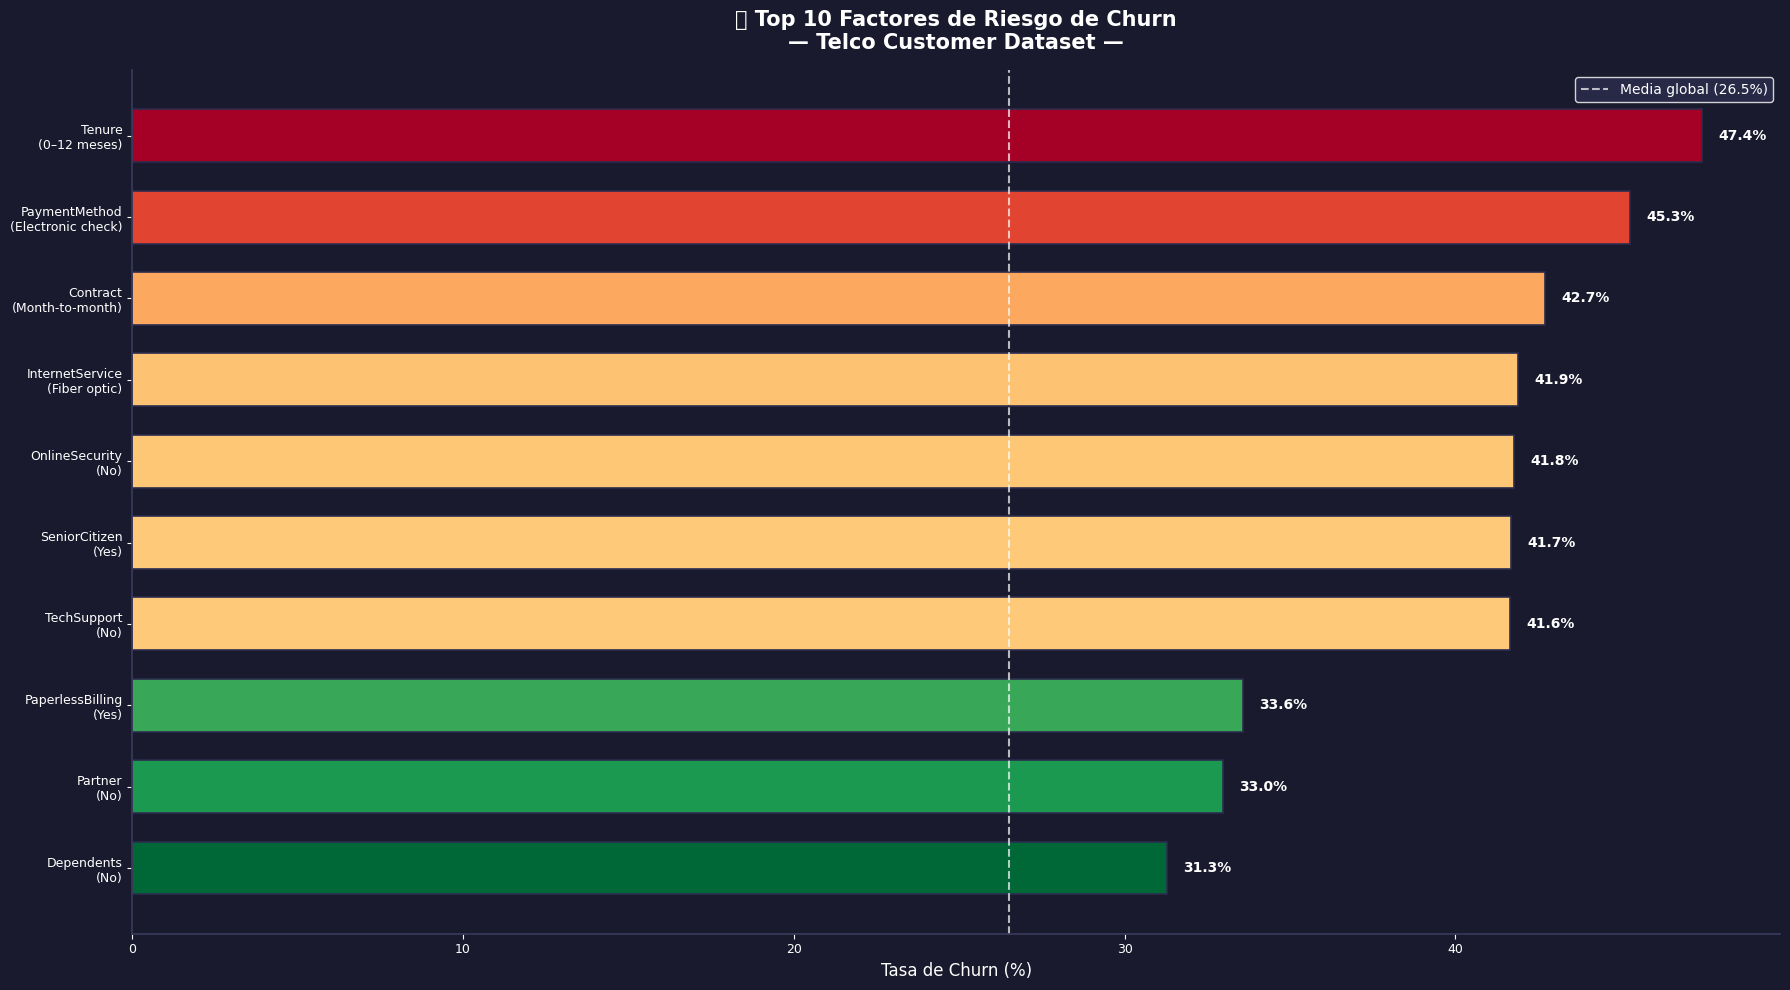

In [ ]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#1A1A2E')

# ── Calcular top insights ────────────────────────────────────
insights = [
    ('Contract\n(Month-to-month)', df[df['Contract']=='Month-to-month']['Churn_bin'].mean()*100),
    ('InternetService\n(Fiber optic)', df[df['InternetService']=='Fiber optic']['Churn_bin'].mean()*100),
    ('PaymentMethod\n(Electronic check)', df[df['PaymentMethod']=='Electronic check']['Churn_bin'].mean()*100),
    ('OnlineSecurity\n(No)', df[df['OnlineSecurity']=='No']['Churn_bin'].mean()*100),
    ('TechSupport\n(No)', df[df['TechSupport']=='No']['Churn_bin'].mean()*100),
    ('SeniorCitizen\n(Yes)', df[df['SeniorCitizen']==1]['Churn_bin'].mean()*100),
    ('PaperlessBilling\n(Yes)', df[df['PaperlessBilling']=='Yes']['Churn_bin'].mean()*100),
    ('Partner\n(No)', df[df['Partner']=='No']['Churn_bin'].mean()*100),
    ('Tenure\n(0–12 meses)', df[df['tenure']<=12]['Churn_bin'].mean()*100),
    ('Dependents\n(No)', df[df['Dependents']=='No']['Churn_bin'].mean()*100),
]
insights_sorted = sorted(insights, key=lambda x: x[1], reverse=True)
labels_ins = [x[0] for x in insights_sorted]
values_ins = [x[1] for x in insights_sorted]

ax = fig.add_subplot(111)
ax.set_facecolor('#1A1A2E')

cmap   = plt.cm.RdYlGn_r
colors_ins = [cmap((v - min(values_ins)) / (max(values_ins) - min(values_ins)))
              for v in values_ins]

bars = ax.barh(labels_ins[::-1], values_ins[::-1],
               color=colors_ins[::-1], edgecolor='#2C2C4E',
               linewidth=1.2, height=0.65)

ax.axvline(26.5, color='white', linestyle='--', lw=1.5, alpha=0.7,
           label='Media global (26.5%)')
ax.set_xlabel('Tasa de Churn (%)', color='white', fontsize=12)
ax.set_title('🚨 Top 10 Factores de Riesgo de Churn\n— Telco Customer Dataset —',
             color='white', fontsize=15, fontweight='bold', pad=15)
ax.tick_params(colors='white', labelsize=9)
ax.spines['bottom'].set_color('#3A3A5E')
ax.spines['left'].set_color('#3A3A5E')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('#1A1A2E')
ax.legend(facecolor='#2C2C4E', edgecolor='white',
          labelcolor='white', fontsize=10)

for bar, val in zip(bars, values_ins[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color='white',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Conclusiones

### 9.1 Hallazgos principales del EDA

| # | Variable | Hallazgo | Tasa de Churn | Acción sugerida |
|---|----------|----------|---------------|-----------------|
| 1 | **Contract** | Contratos mes a mes tienen ~43% de churn | 43% vs 3% (2 años) | Incentivar conversión a contratos anuales con descuento |
| 2 | **Tenure** | El 47% del churn ocurre en los primeros 12 meses | 47% en cohorte 0–12m | Onboarding activo + contacto proactivo mes 3 y 6 |
| 3 | **InternetService** | Fibra óptica concentra el mayor churn | ~42% | Auditar calidad y precio vs. competencia en fibra |
| 4 | **PaymentMethod** | E-check duplica la tasa de churn | ~45% | Ofrecer incentivos para migrar a pago automático |
| 5 | **OnlineSecurity** | Sin seguridad → 42% churn | 42% vs 15% con seguridad | Ofrecer período de prueba gratuito de seguridad online |
| 6 | **SeniorCitizen** | Adultos mayores abandonan al doble de tasa | ~42% | Programa de atención preferencial para este segmento |
| 7 | **MonthlyCharges** | Churn más alto en $70–90/mes | Media $74 vs $61 (no churn) | Revisar propuesta de valor en el rango de precio premium |

### 9.2 Perfil del cliente de mayor riesgo

> Cliente nuevo (< 12 meses) · Fibra óptica · Contrato mes a mes · Pago con cheque electrónico · Sin servicios de seguridad/soporte · Sin pareja ni dependientes · Cargo mensual > $70

Este perfil concentra tasas de churn superiores al **65%** y debe ser el objetivo prioritario de cualquier campaña de retención.

### 9.3 Variables recomendadas para el modelo predictivo
En orden de importancia según el EDA:
1. `Contract` (V de Cramér > 0.40)
2. `tenure` (correlación -0.35 con Churn)
3. `InternetService`
4. `OnlineSecurity` / `TechSupport`
5. `PaymentMethod`
6. `MonthlyCharges`
7. `SeniorCitizen`
8. `PaperlessBilling`

In [ ]:
def render_strategic_findings(df):
    st.markdown('<div id="insights"></div>', unsafe_allow_html=True)
    st.markdown("<h2 style='color:#00D1FF;'>7. Síntesis Estratégica y Matriz de Riesgo</h2>", unsafe_allow_html=True)
    
    # Datos de la tabla transformados a objetos de visualización
    findings = [
        {"var": "CONTRACT", "val": "43%", "desc": "Mes a mes", "action": "Incentivar conversión anual"},
        {"var": "TENURE", "val": "47%", "desc": "Cohorte 0–12m", "action": "Onboarding proactivo"},
        {"var": "INTERNET", "val": "42%", "desc": "Fibra Óptica", "action": "Auditoría de calidad"},
        {"var": "PAYMENT", "val": "45%", "desc": "Electronic Check", "action": "Migrar a pago automático"},
        {"var": "SECURITY", "val": "42%", "desc": "Sin Protección", "action": "Trial de seguridad online"},
        {"var": "SENIOR", "val": "42%", "desc": "Adulto Mayor", "action": "Atención preferencial"},
        {"var": "CHARGES", "val": "High", "desc": "Rango $70–90", "action": "Revisar valor premium"}
    ]

    # Renderizado en Grid de 4 columnas para alta densidad
    cols = st.columns(4)
    for i, item in enumerate(findings):
        with cols[i % 4]:
            st.markdown(f"""
                <div style="
                    background: #0A0A0A; 
                    border: 1px solid #1A1A1A; 
                    border-left: 4px solid #00D1FF; 
                    padding: 20px; 
                    border-radius: 4px;
                    margin-bottom: 20px;
                    height: 180px;
                ">
                    <p style="color: #555; font-size: 10px; font-weight: 800; letter-spacing: 1px; margin: 0;">{item['var']}</p>
                    <h3 style="color: #00D1FF; margin: 5px 0; font-size: 24px;">{item['val']} <span style="font-size: 12px; color: #E0E0E0;">Churn</span></h3>
                    <p style="color: #E0E0E0; font-size: 12px; font-weight: 600; margin-bottom: 10px;">{item['desc']}</p>
                    <div style="background: rgba(0, 209, 255, 0.1); padding: 8px; border-radius: 4px;">
                        <p style="color: #00D1FF; font-size: 11px; margin: 0; line-height: 1.2;"><b>ACCIÓN:</b> {item['action']}</p>
                    </div>
                </div>
            """, unsafe_allow_html=True)

    st.write("##")

    # Gráfico de Dispersión de Impacto (Reemplazo visual de la tabla)
    st.markdown("#### Mapa de Calor de Prioridades (Impacto vs Probabilidad)")
    
    # Creamos un dataframe para un scatter plot que posicione los hallazgos
    impact_data = pd.DataFrame({
        'Variable': [f['var'] for f in findings],
        'Probabilidad': [43, 47, 42, 45, 42, 42, 38], # Basado en tus tasas
        'Impacto_Negocio': [9, 10, 8, 7, 6, 5, 9]      # Estimación lógica
    })

    fig_impact = px.scatter(
        impact_data, x='Probabilidad', y='Impacto_Negocio', text='Variable',
        size='Probabilidad', color='Probabilidad',
        color_continuous_scale=['#1E2127', '#00D1FF'],
        labels={'Probabilidad': 'Tasa de Churn (%)', 'Impacto_Negocio': 'Impacto en Revenue (1-10)'}
    )
    
    fig_impact.update_traces(textposition='top center', marker=dict(line=dict(width=1, color='white')))
    fig_impact.update_layout(
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        showlegend=False,
        height=400
    )
    
    st.plotly_chart(fig_impact, use_container_width=True)